In [33]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv
from langchain_google_genai  import ChatGoogleGenerativeAI

load_dotenv()


llm =  ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",
    temperature=0)

In [34]:
class EmployeeStete(TypedDict):
    employee_name : str
    monthly_salary: int
    working_days: int
    completed_projects: int

    yearly_salary: int
    bonus_amount: int
    project_status: str
    summary: str
    


In [35]:
def calculate_yearly_salary(state:EmployeeStete):
    yearly_salary = state['monthly_salary'] * 12
    return {'yearly_salary':yearly_salary}


def calculate_bonus(state:EmployeeStete):
    yearly_salary = state.get('yearly_salary', state['monthly_salary'] * 12)
    bonus = yearly_salary * 0.2
    return {'bonus_amount': bonus}


def project_evaluation(state:EmployeeStete):
    if state['completed_projects'] >=5:
        status = 'Excellent'
    else:
        status = 'Average'
    return {'project_status': status}


def summary(state:EmployeeStete):
    summary_text = (
        f"Employee {state['employee_name']} has an yearly salary of {state['yearly_salary']} "
        f"with bonus {state['bonus_amount']} with status as {state['project_status']}"
    )
    return {'summary': summary_text}


In [36]:
graph = StateGraph(EmployeeStete)

graph.add_node('calculate_yearly_salary', calculate_yearly_salary)
graph.add_node('calculate_bonus', calculate_bonus)
graph.add_node('project_evaluation', project_evaluation)
graph.add_node('summary', summary)

graph.add_edge(START, 'calculate_yearly_salary')
graph.add_edge(START, 'calculate_bonus')
graph.add_edge(START, 'project_evaluation')

graph.add_edge('calculate_yearly_salary', 'summary')
graph.add_edge('calculate_bonus', 'summary')
graph.add_edge('project_evaluation', 'summary')

graph.add_edge('summary', END)



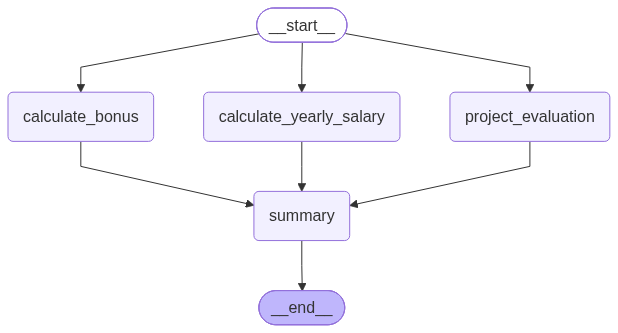

In [37]:
workflow = graph.compile()
workflow

In [38]:
initial_state = {'employee_name' : 'John smith',
    'monthly_salary': 5000000,
    'working_days': 29,
    'completed_projects': 50}

result = workflow.invoke(initial_state)

In [39]:
result

{'employee_name': 'John smith',
 'monthly_salary': 5000000,
 'working_days': 29,
 'completed_projects': 50,
 'yearly_salary': 60000000,
 'bonus_amount': 12000000.0,
 'project_status': 'Excellent',
 'summary': 'Employee John smith has an yearly salary of 60000000 with bonus 12000000.0 with status as Excellent'}